In [1]:
%matplotlib notebook
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import glob, os
from scipy.signal import medfilt
CS8_DC = 0.6 #CF32 (or 32 bit) centers on 127.4, CS8 (or 8 bit) centers on 128 


def load_iq_files(meta_file):
    data = np.load(meta_file, allow_pickle = True)
    iq = data["iq_files"]
    base = os.path.dirname(meta_file)
    iq_file = []
    i=0
    for file_name in iq:
        raw = (np.fromfile(os.path.join(base, file_name), dtype = data["dtype"][0]))

        if data["dtype"][0] == 'int8':
            raw = ((raw[0::2] + CS8_DC) + 1j*(raw[1::2] + CS8_DC)) / 128
            raw = raw.astype(np.complex64)
        iq_file.append(raw)
        print(f"{len(iq_file[i])} samples, var {np.var(iq_file[i]):.7f}")
        i+=1
    return iq_file


def windowed_delay(a, b, maxlag, n_chunks = 16):
    assert len(a) == len(b)
    c = np.array_split(a, n_chunks)
    d = np.array_split(b, n_chunks)
    peak_lag = []
    ratio = []
    for i in range(n_chunks):
        lags, scores = xcorr_fft(c[i], d[i], maxlag)
        mag = np.abs(scores)
        peak_lag.append(lags[np.argmax(mag)])
        peak = np.abs(scores[np.argmax(np.abs(scores))])
        floor = np.sqrt(np.mean(np.delete(mag, np.argmax(mag))**2))
        ratio.append(peak/floor)
    chunk_seconds = (len(a)/2.048e6)/n_chunks
    times = ((np.arange(n_chunks) + 0.5) * chunk_seconds)
    return peak_lag, ratio, times
          

def xcorr_fft(a, b, maxlag):
    assert len(a) == len(b)
    N=len(a)
    Var_ceiling = np.ceil(np.log2(N + maxlag))
    power = 2 ** int(Var_ceiling)
    c = np.fft.ifft(np.fft.fft(a, power) * np.conj(np.fft.fft(b, power)))
    lags = np.arange(-maxlag, maxlag+1)
    scores = c[(-lags) % power]
    
    return lags, scores

          
def xcorr_brute(a, b, maxlag):
    assert len(a) == len(b)
    L_scores = []
    N = len(a)
    for L in range(-maxlag, maxlag+1):
        if L >= 0:
            slice_a = a[:N-L]
            slice_b = b[L:]
        else:
            slice_a = a[-L:]
            slice_b = b[:N+L]
        L_scores.append(np.sum(slice_a * np.conj(slice_b)))
    lags = np.arange(-maxlag, maxlag+1)
    L_scores = np.array(L_scores)
    return lags, L_scores
        
def plot_corr(times, slope, intercept, peak_lag):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    ax.plot(times, peak_lag, "o", color="#2e6fb7", label="measured delay (per 0.25 s chunk)")
    ax.plot(times, slope * times + intercept,
            color="#c2503b", linewidth=2,
            label=f"fit: {slope:.2f} samples/s  →  {abs(slope)/2.048:.2f} ppm")
    
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Measured delay (samples)")
    ax.set_title("Delay drift between free-running receivers (1 ppm injected)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    fig.tight_layout()
    fig.savefig("drift_staircase.png", dpi=150)

def rotation_correction(a, b, maxlag):
    '''
    returns b -> rotated so its peak phase matches a's peak phase
    '''
    lags, scores = xcorr_fft(a, b, maxlag)
    peak_score = scores[np.argmax(np.abs(scores))]
    theta = np.angle(peak_score)
    b_fixed = b * np.exp(1j * theta)
    return theta, b_fixed

def acquire(a, b):
    assert len(a) == len(b)
    N=len(a)
    a = a - np.mean(a)
    b = b - np.mean(b)
    Var_ceiling = np.ceil(np.log2(N*2))
    power = 2 ** int(Var_ceiling)
    c = np.fft.ifft(np.fft.fft(a, power) * np.conj(np.fft.fft(b, power)))
    mag = np.abs(c)
    m = np.argmax(mag)
    lag = -m if m<=power//2 else power-m
    floor = np.sqrt(np.mean(np.delete(mag, m)**2))
    peak = mag[m]
    ratio = peak/floor
    return lag, ratio

def align(a, b, lag):
    if lag > 0:
        a_al = a[:-lag]
        b_al = b[lag:]
    elif lag < 0:
        a_al = a[-lag:]
        b_al = b[:lag]
    else:
        a_al = a
        b_al = b
    return a_al, b_al


def cross_spectrum(a, b, veclength = 1024, samp_rate = 2.048e6):
    n_chunks = len(a)//veclength
    a = a[:n_chunks*veclength]
    b = b[:n_chunks*veclength]
    c = np.array_split(a, n_chunks)
    d = np.array_split(b, n_chunks)
    X_ab = []
    window = np.blackman(veclength)
    for i in range(n_chunks):
        c_mean = np.mean(c[i])
        d_mean = np.mean(d[i])
        c[i] = c[i] - c_mean
        d[i] = d[i] - d_mean
        X_ab.append(np.fft.fft(c[i] * window) * np.conj(np.fft.fft(d[i] * window)))
    X_ab = np.mean(X_ab, axis = 0)
    freqs = np.fft.fftfreq(veclength, 1/samp_rate)
    return freqs, X_ab


def delay_from_spectrum(freqs, X_ab, tau_max = 0.5, dtau = 0.001):
    #we already removed the integer lag with aquire, so tau can only span ±0.5 or else it would round  
    samp_rate = len(freqs) * (freqs[1]-freqs[0]) # we space by samp_rate in cross_spectrum so we can find it again here
    freq_norm = freqs / samp_rate
    keep = (np.abs(freq_norm) > 0.01) & (np.abs(freq_norm) < 0.4) #RTLs have inherent DC spikes at the beginning and attenuates at the end
    freq_norm = freq_norm[keep]
    X_ab  = X_ab[keep]
    tau_grid = np.arange(-tau_max, tau_max, dtau)
    Search = []
    for i in range(len(tau_grid)):
        Search.append(np.abs(np.sum(X_ab* np.exp(-2j* np.pi * freq_norm * tau_grid[i])))) #searching the full tau range. the correct tau value will align in all bins and add, the wrong tau value will cancel
    Search = np.array(Search)
    peak = np.argmax(Search)
    tau = tau_grid[peak]
    floor = np.sqrt(np.sum(np.abs(X_ab)**2))    
    ratio = Search[peak]/floor
    return tau, ratio, tau_grid, Search

def anti_slip(a, b):
    pass



0. 30 sec no rf transmitter
0. rf in front
0. rf to the left side (left facing telescope)
0. rf on other side
0. no rf
0. 60 sec no rf pointed at betelgeuse
0. 60 sec with rf pointed at betelgeuse

All had center freq at 1419.99MHz.

In [2]:
data_dir = '/Volumes/Kenny/Interferometry-08-07-2026/'
metas = np.sort(glob.glob(data_dir + '*.npz'))
print(metas)

['/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_13-46-08.845216.metadata.npz'
 '/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_13-49-11.425619.metadata.npz'
 '/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_13-51-19.003208.metadata.npz'
 '/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_13-53-02.585988.metadata.npz'
 '/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_13-54-23.891734.metadata.npz'
 '/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_14-04-31.524022.metadata.npz'
 '/Volumes/Kenny/Interferometry-08-07-2026/2026-08-07_14-10-12.249982.metadata.npz']


In [3]:
data = load_iq_files(metas[3])

61440000 samples, var 0.0404734
61440000 samples, var 0.0850754


In [63]:
# data[0]=data[0][:len(data[1])]
# assert len(data[0]) == len(data[1])

In [4]:
N=len(data[0])
data[0] = data[0] - np.mean(data[0])
data[1] = data[1] - np.mean(data[1])
Var_ceiling = np.ceil(np.log2(N*2))
power = 2 ** int(Var_ceiling)
c = np.fft.ifft(np.fft.fft(data[0], power) * np.conj(np.fft.fft(data[1], power)))
mag = np.abs(c)
m = np.argmax(mag)
lag = -m if m<=power//2 else power-m
floor = np.sqrt(np.mean(np.delete(mag, m)**2))
peak = mag[m]
ratio = peak/floor
print(m)
print(peak)
print(floor)
print(lag)

134212418
330875.3454336008
326.6077813207965
5310


<IPython.core.display.Javascript object>


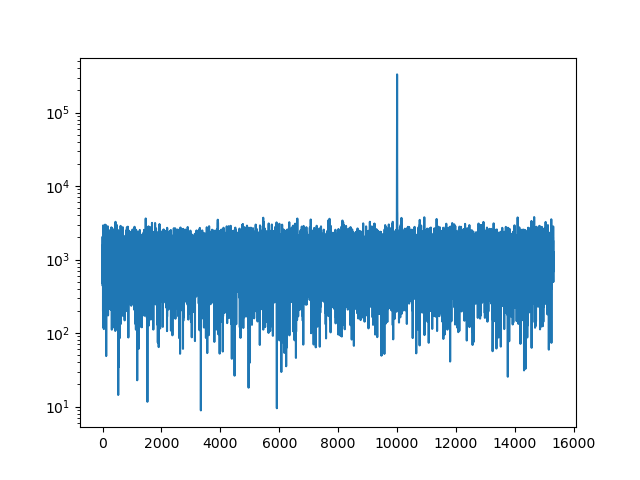

In [46]:
plt.figure()
x=10000
plt.semilogy(mag[(m-x):(m+x)])

In [ ]:
plt.figure()
plt.plot(mag[m-1000:m+1000])
plt.show()

<IPython.core.display.Javascript object>

In [6]:
wf1 = np.fft.fftshift(np.fft.fft(data[0].reshape(-1, 1024)), axes=-1)
wf2 = np.fft.fftshift(np.fft.fft(data[1].reshape(-1, 1024)), axes=-1)

<IPython.core.display.Javascript object>


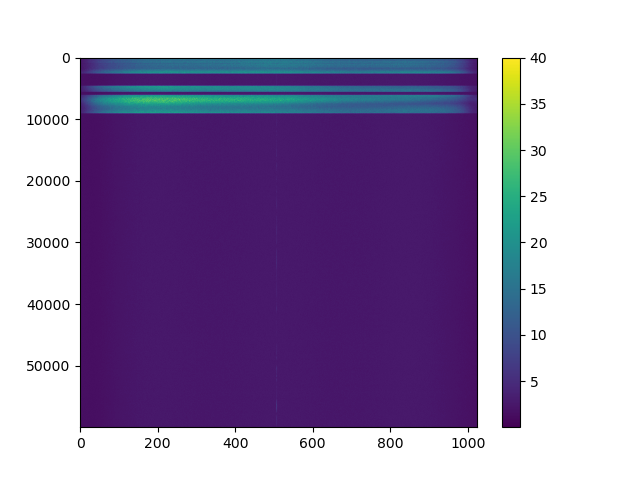

In [7]:
plt.figure()
plt.imshow(np.abs(wf1), vmax=40, aspect='auto')
plt.colorbar()

In [8]:
auto1 = cross_spectrum(data[0], data[0])
auto2 = cross_spectrum(data[1], data[1])
cross = cross_spectrum(data[0], data[1])

<IPython.core.display.Javascript object>


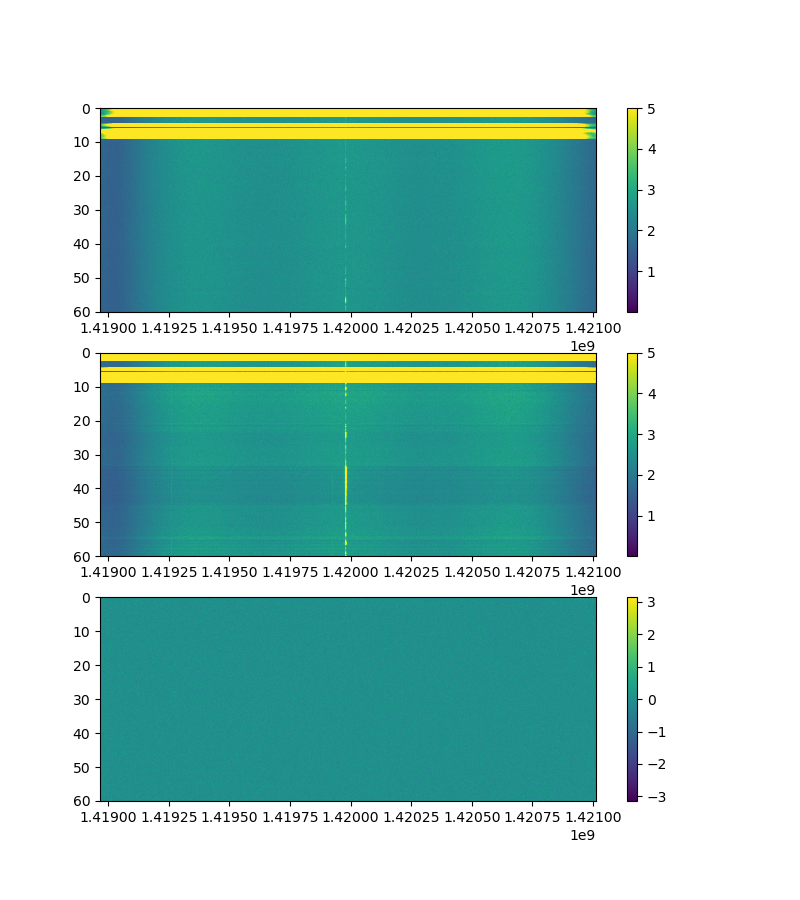

In [9]:
plt.figure(figsize=(8,9))
plt.subplot(311)
plt.imshow(np.abs(wf1), aspect='auto', vmax=5, extent=[auto1[0].min()+1419.990e6, auto1[0].max()+1419.990e6, 60, 0])
plt.colorbar()
plt.subplot(312)
plt.imshow(np.abs(wf2), aspect='auto', vmax=5, extent=[auto2[0].min()+1419.990e6, auto2[0].max()+1419.990e6, 60, 0])
plt.colorbar()
plt.subplot(313)
# plt.imshow(np.abs(wf1*np.conj(wf2)), aspect='auto', vmax=25, extent=[auto2[0].min()+1419.990e6, auto2[0].max()+1419.990e6, 60, 0])
plt.imshow(np.angle(wf1*np.conj(wf2)), aspect='auto', vmin=-np.pi, vmax=np.pi, extent=[auto2[0].min()+1419.990e6, auto2[0].max()+1419.990e6, 60, 0])
plt.colorbar()

<IPython.core.display.Javascript object>


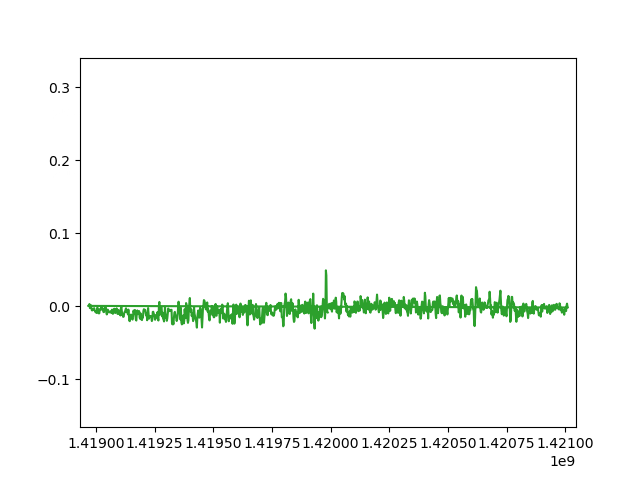

/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


In [47]:
plt.figure()
plt.plot(auto1[0]+1419.990e6, auto1[1])
plt.plot(auto2[0]+1419.990e6, auto2[1])
plt.plot(cross[0]+1419.990e6, cross[1])

In [11]:
a, b = align(data[0], data[1], lag)

In [12]:
len_use = (len(a) // 1024) * 1024
wf1 = np.fft.fftshift(np.fft.fft(a[:len_use].reshape(-1, 1024)), axes=-1)
wf2 = np.fft.fftshift(np.fft.fft(b[:len_use].reshape(-1, 1024)), axes=-1)

In [49]:
auto1 = cross_spectrum(a, a)
auto2 = cross_spectrum(b, b)
cross = cross_spectrum(a, b)

<IPython.core.display.Javascript object>


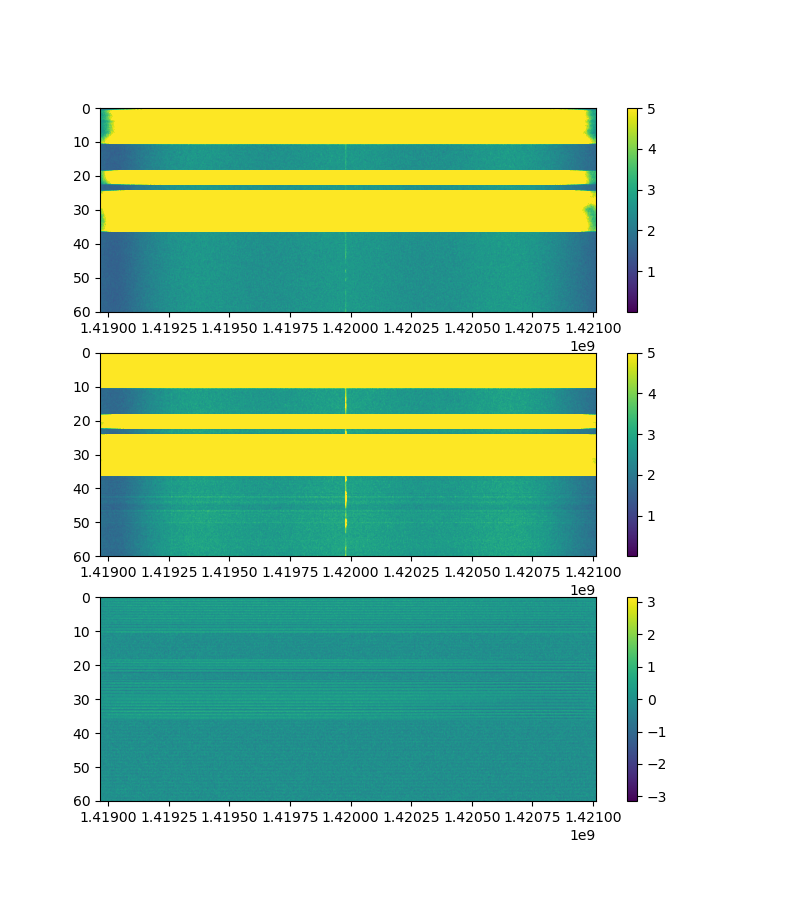

In [15]:
plt.figure(figsize=(8,9))
plt.subplot(311)
plt.imshow(np.abs(wf1[:15000]), aspect='auto', vmax=5, extent=[auto1[0].min()+1419.990e6, auto1[0].max()+1419.990e6, 60, 0])
plt.colorbar()
plt.subplot(312)
plt.imshow(np.abs(wf2[:15000]), aspect='auto', vmax=5, extent=[auto2[0].min()+1419.990e6, auto2[0].max()+1419.990e6, 60, 0])
plt.colorbar()
plt.subplot(313)
# plt.imshow(np.abs(wf1*np.conj(wf2)), aspect='auto', vmax=25, extent=[auto2[0].min()+1419.990e6, auto2[0].max()+1419.990e6, 60, 0])
plt.imshow(np.angle(wf1[:15000]*np.conj(wf2[:15000])), aspect='auto', vmin=-np.pi, vmax=np.pi, extent=[auto2[0].min()+1419.990e6, auto2[0].max()+1419.990e6, 60, 0])
plt.colorbar()

<IPython.core.display.Javascript object>


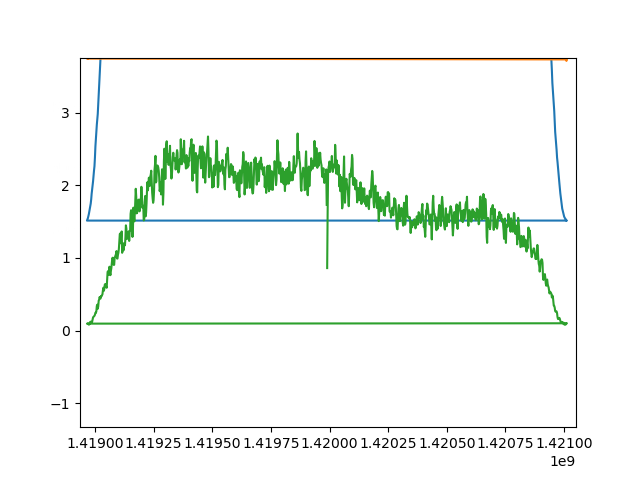

/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


In [53]:
plt.figure()
plt.plot(auto1[0]+1419.990e6, auto1[1])
plt.plot(auto2[0]+1419.990e6, auto2[1])
plt.plot(cross[0]+1419.990e6, np.abs(cross[1]))

In [17]:
lag2, ratio2 = acquire(a[(1024*12000):], b[(1024*12000):])
print(lag2, ratio2)

In [54]:
auto1 = cross_spectrum(a[(1024*12000):], a[(1024*12000):])
auto2 = cross_spectrum(b[(1024*12000):], b[(1024*12000):])
cross = cross_spectrum(a[(1024*12000):], b[(1024*12000):])

<IPython.core.display.Javascript object>


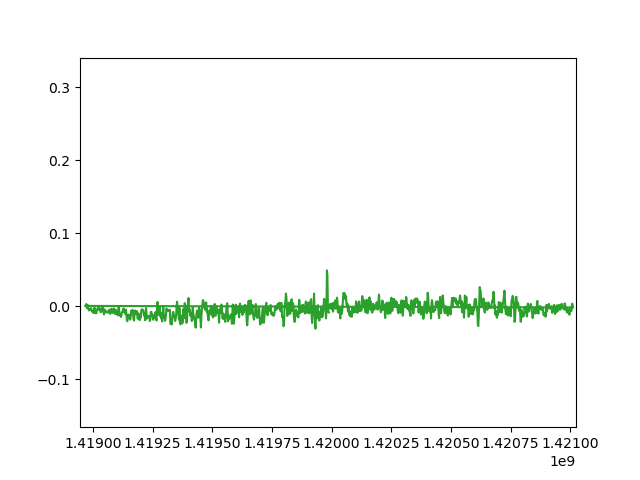

/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/abeardsley/code/miniconda3/envs/phys340/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


In [58]:
plt.figure()
plt.plot(auto1[0]+1419.990e6, auto1[1])
plt.plot(auto2[0]+1419.990e6, auto2[1])
plt.plot(cross[0]+1419.990e6, np.real(cross[1]))

In [36]:
cross_smooth = medfilt(cross[1].real, 11) + 1j * medfilt(cross[1].imag, 11)
ph = np.angle(cross_smooth)
# ph = np.unwrap(ph)
# ph[ph < -4] = ph[ph < -4] + 2*np.pi
ph[ph >0] = ph[ph > 0] - 2*np.pi
ph[ph < -2*np.pi] = ph[ph <-2*np.pi] + 2*np.pi

<IPython.core.display.Javascript object>


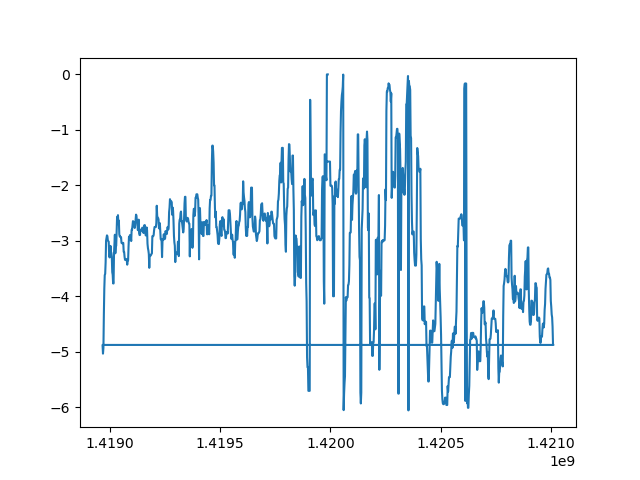

In [37]:
plt.figure()
plt.plot(cross[0]+1419.990e6, ph)